<!-- [intro] -->
# EXPERIMENT — Windows 10 headwind retune to match post-seam actuals

**This notebook is an experiment, not a forecast change.** It does not edit
`data-official/2026-08/adjustments/headwind.json` or any other live spec. Nothing it produces is
canonical, published, or adopted until a human explicitly promotes it.

## What this asks

Since the August build's seam (2026-08-02, trained through 2026-08-01), actual desktop DAU has come
in above the published, headwind-adjusted forecast, and the gap is growing. This notebook asks: **if
we hold everything else fixed (model config, `l`/`o` overlays, ramp shape, ramp start date) and only
vary the Windows 10 headwind's Dec-15 magnitude, what value best matches the actual data observed so
far?**

- Scope: **desktop only.** Mobile's `h`/`t` are untouched.
- IR/CN are **included as-is** — no ex-IR/CN adjustment, no netting of other confounds. The fit is
  against the world-total ALL-desktop series exactly as published.
- The ramp **shape and start date are fixed** (linear ramp, `start_date` = the live spec's
  2026-08-02, `anchor_date` = 2026-12-15). Only the Dec-15 anchor magnitude is the free parameter.
- Fit window: every date from the ramp's `start_date` through the most recent landed actual — which,
  since the ramp starts at the seam, is exactly the new post-seam data.
- Objective: plain (unweighted) RMSE over the fit window.
- The best-fit anchor is reported **whatever it comes out to be** — no floor at zero, no requirement
  that it remain a "headwind" in sign.

## Why this can be solved in closed form, not just grid-searched

The headwind is a **display-layer** adjustment (`src/mozaic_daily/adjustments.py`): it is added to
the 28-day MA *after* mozaic, as `anchor_dau * elapsed_days / total_days` from `start_date` to
`anchor_date`. Because that ramp is **linear in the anchor magnitude**, the forecast curve for any
candidate anchor is a fixed base curve (raw model + `l` + `o`, no `h`/`t`) plus `anchor * f(t)`, where
`f(t)` is a known weight in `[0, 1]`. RMSE against actuals is therefore an exact convex quadratic in
the anchor, with one exact minimum — a textbook weighted least-squares problem, solvable directly
(no iteration needed). We compute that closed-form optimum **and** sweep a grid around it, so the
result can be read either as "the answer" or as "the shape of the tradeoff."

## Self-contained

This notebook does not reconcile its result against `research/headwinds/WIN10_ANCHOR_FINDINGS.md` or
any other prior headwind-magnitude analysis. Those conclusions were not validated against human
judgment before being recorded and should not be treated as a prior to reconcile with here — this is
a standalone exercise in matching the specific data observed since the August seam.


In [1]:
# [setup]
import os
import subprocess
import sys
import glob
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

# Anchor execution at git root so relative paths work regardless of notebook location.
os.chdir(subprocess.run(['git', 'rev-parse', '--show-toplevel'],
                        capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")

from mozaic_daily.seam_ma import display_ma, daily_to_28ma  # noqa: E402
from mozaic_daily.adjustments import (  # noqa: E402
    load_forecast,
    load_adjustments_from_dir,
    apply_net_adjustment_to_series,
    render_adjustment,
)

# --- Live August build (unchanged inputs -- this experiment only varies the headwind anchor) ---
DESKTOP_FORECAST_PATH = (
    "data-official/2026-08/desktop_g01_2026-08-02/"
    "cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative/"
    "mozaic_daily_forecast.2026-08-02.ld-D.adj-lo.parquet"
)
PREV_FORECAST_DESKTOP_PATH = (
    "data-official/2026-07/desktop_locked/"
    "mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet"
)
ADJUSTMENTS_DIR = "data-official/2026-08/adjustments"
PREV_ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"
LIVE_HEADWIND_SPEC_PATH = f"{ADJUSTMENTS_DIR}/headwind.json"

OUT_DIR = "research/headwinds/aug-post-seam-retune"
PLOTS_DIR = f"{OUT_DIR}/plots"
RESULTS_DIR = f"{OUT_DIR}/results"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-08-02")        # desktop seam
PREV_FORECAST_START = pd.Timestamp("2026-07-06")   # July's seam
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")

STAKEHOLDER_DESKTOP_LOW = 49_039_852
STAKEHOLDER_DESKTOP_BASELINE = 49_513_157
STAKEHOLDER_DESKTOP_STRETCH = 49_772_388

print(f"cwd: {os.getcwd()}")
print(f"seam: {FORECAST_START.date()} | prior seam: {PREV_FORECAST_START.date()}")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


cwd: /Users/brendanwells/work/mozaic-daily
seam: 2026-08-02 | prior seam: 2026-07-06


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [helpers]
def load_all_level_dau(path, data_source, segment_filter, app_filter, *, require_state):
    """Load a validated forecast parquet, return World(ALL) daily DAU with data_type."""
    df, meta = load_forecast(path, require_state=require_state)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == segment_filter)
        & (df["data_source"] == data_source)
        & (df["app_name"] == app_filter)
    )
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True), meta


def millions_formatter(x, pos):
    # Two decimals so adjacent ~0.5M-spaced ticks stay distinct.
    return f"{x / 1e6:.2f}M"


def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_forecast_only(s, forecast_start=FORECAST_START):
    return s[(s.index >= forecast_start) & (s.index <= DISPLAY_END)].dropna()


def add_experiment_watermark(ax, text="EXPERIMENT"):
    """Large diagonal watermark -- this chart is not a canonical/published deliverable."""
    ax.text(0.5, 0.5, text, transform=ax.transAxes, fontsize=110, color="#c0392b",
            alpha=0.18, ha="center", va="center", rotation=28, zorder=100,
            fontweight="bold", clip_on=True)


In [3]:
# [load-parquets]
# Same artifacts the canonical August notebook uses -- this experiment changes nothing about the
# model, l/o overlays, or the July comparison. Only the headwind anchor varies, and only downstream
# of this cell.
desktop_raw, desktop_meta = load_all_level_dau(
    DESKTOP_FORECAST_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=["l", "o"])
prev_desktop_raw, prev_desktop_meta = load_all_level_dau(
    PREV_FORECAST_DESKTOP_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=["l", "o"])

last_train = desktop_raw.loc[desktop_raw["data_type"] == "training", "target_date"].max()
print(f"Desktop (g01, live):  {len(desktop_raw)} rows, "
      f"{desktop_raw['target_date'].min().date()} to {desktop_raw['target_date'].max().date()} "
      f"| seam {FORECAST_START.date()} | last training day {last_train.date()}")
print(f"Desktop (prior, July): {len(prev_desktop_raw)} rows, "
      f"{prev_desktop_raw['target_date'].min().date()} to {prev_desktop_raw['target_date'].max().date()}")

with open(LIVE_HEADWIND_SPEC_PATH) as f:
    live_headwind_spec = json.load(f)
assert live_headwind_spec["type"] == "linear_ramp"
RAMP_START = pd.Timestamp(live_headwind_spec["start_date"])
RAMP_ANCHOR_DATE = pd.Timestamp(live_headwind_spec["anchor_date"])
LIVE_ANCHOR_DAU = live_headwind_spec["desktop_dau"]
RAMP_TOTAL_DAYS = (RAMP_ANCHOR_DATE - RAMP_START).days
print(f"\nLive headwind spec: start {RAMP_START.date()} -> anchor {RAMP_ANCHOR_DATE.date()} "
      f"({RAMP_TOTAL_DAYS} days), desktop_dau={LIVE_ANCHOR_DAU:,.0f}")
assert RAMP_START == FORECAST_START, (
    "This experiment assumes the ramp starts exactly at the desktop seam -- fixed by design "
    "(shape and start date are held fixed per the experiment's scope)."
)


Desktop (g01, live):  2922 rows, 2020-01-01 to 2027-12-31 | seam 2026-08-02 | last training day 2026-08-01
Desktop (prior, July): 2922 rows, 2020-01-01 to 2027-12-31

Live headwind spec: start 2026-08-02 -> anchor 2026-12-15 (135 days), desktop_dau=-1,315,000


In [4]:
# [bq-actuals]
# Only the POST-SEAM window needs a fresh BigQuery pull: everything through the last training day
# (2026-08-01) is already in the parquet's "training" rows, which verify_training_rows_are_actuals.py
# guarantees are byte-identical to raw actuals -- so reusing them here saves a ~780GB-equivalent
# full-year rescan of active_users_aggregates. Query scope matches production exactly: world total
# (no country filter), Legacy telemetry, app_name = "Firefox Desktop". Cutoff is LA-time -2 days,
# same convention as the canonical notebook, because the most-recent landed day can be partial.
client = bigquery.Client(project="moz-fx-data-bq-data-science")

t0 = time.time()
sys.stdout.write(f"[BQ] post-seam desktop actuals from {FORECAST_START.date()}...")
sys.stdout.flush()
post_seam_actuals = client.query(f"""
    SELECT submission_date AS target_date, SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop"
      AND submission_date >= '{FORECAST_START.date()}'
      AND submission_date <= CURRENT_DATE("America/Los_Angeles") - 2
    GROUP BY submission_date
    ORDER BY 1
""").to_dataframe()
post_seam_actuals["target_date"] = pd.to_datetime(post_seam_actuals["target_date"])
sys.stdout.write(f" {len(post_seam_actuals)} rows, through {post_seam_actuals['target_date'].max().date()} "
                 f"({time.time() - t0:.1f}s elapsed)\n")
sys.stdout.flush()

assert post_seam_actuals["target_date"].min() == FORECAST_START, (
    "Fresh pull should start exactly at the seam -- a gap here would mean training rows and the "
    "fresh pull don't stitch into one continuous daily series."
)
LAST_ACTUAL_DATE = post_seam_actuals["target_date"].max()
print(f"Last landed actual day: {LAST_ACTUAL_DATE.date()} "
      f"({(LAST_ACTUAL_DATE - FORECAST_START).days + 1} days of new post-seam data)")


[BQ] post-seam desktop actuals from 2026-08-02...

 15 rows, through 2026-08-16 (4.7s elapsed)


Last landed actual day: 2026-08-16 (15 days of new post-seam data)


In [5]:
# [compute-series]
# Actuals: stitch parquet training rows (Jan 1 .. last training day, byte-identical to raw actuals)
# with the fresh post-seam pull into one continuous daily series, then take a plain 28d MA -- exactly
# how the canonical notebook's "Actuals" line is built, just assembled from two sources instead of
# one BQ pull.
training_actuals = desktop_raw.loc[
    desktop_raw["data_type"] == "training", ["target_date", "dau"]
]
daily_actuals = (
    pd.concat([training_actuals, post_seam_actuals[["target_date", "dau"]]], ignore_index=True)
    .drop_duplicates(subset="target_date", keep="last")
    .sort_values("target_date")
)
desktop_actual_ma = daily_to_28ma(daily_actuals["target_date"], daily_actuals["dau"])

# Raw model curve: g01 + l + o, NO h/t. This is the base curve the headwind anchor gets added to.
desktop_raw_ma = display_ma(desktop_raw["target_date"], desktop_raw["dau"], FORECAST_START)
prev_desktop_raw_ma = display_ma(
    prev_desktop_raw["target_date"], prev_desktop_raw["dau"], PREV_FORECAST_START
)

# Published (live) curves -- what's actually on disk today, for comparison.
net_adjustments = load_adjustments_from_dir(ADJUSTMENTS_DIR, desktop_raw_ma.index)
prev_net_adjustments = load_adjustments_from_dir(PREV_ADJUSTMENTS_DIR, prev_desktop_raw_ma.index)

desktop_ma_live = apply_net_adjustment_to_series(
    desktop_raw_ma, net_adjustments, "desktop", forecast_start=FORECAST_START)
prev_desktop_ma = apply_net_adjustment_to_series(
    prev_desktop_raw_ma, prev_net_adjustments, "desktop", forecast_start=PREV_FORECAST_START)

print(f"Live desktop net adjustment at {MEASUREMENT_DATE.date()}: "
      f"{net_adjustments['desktop'].get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")
print(f"Prior (July) desktop net adjustment at {MEASUREMENT_DATE.date()}: "
      f"{prev_net_adjustments['desktop'].get(MEASUREMENT_DATE, float('nan')):+,.0f} DAU")
print(f"\nActuals 28d-MA span: {desktop_actual_ma.dropna().index.min().date()} to "
      f"{desktop_actual_ma.dropna().index.max().date()}")


Live desktop net adjustment at 2026-12-15: -1,315,000 DAU
Prior (July) desktop net adjustment at 2026-12-15: -1,345,000 DAU

Actuals 28d-MA span: 2020-01-28 to 2026-08-16


In [6]:
# [fit-closed-form]
# The ramp is linear in the anchor: forecast_ma(t; A) = raw_ma(t) + A * f(t), f(t) in [0, 1].
# So residual(t; A) = [actual_ma(t) - raw_ma(t)] - A*f(t) = r(t) - A*f(t), and
# RMSE(A)^2 = mean((r - A*f)^2) is an exact convex quadratic in A with one minimum:
#   A* = sum(f*r) / sum(f^2)          (weighted least squares through the origin)
#
# Fit window = every date from the ramp's start_date through the most recent landed actual --
# which, because the ramp starts at the seam, is exactly the new post-seam data.
fit_idx = desktop_actual_ma.dropna().index
fit_idx = fit_idx[(fit_idx >= RAMP_START) & (fit_idx <= LAST_ACTUAL_DATE)]

f = ((fit_idx - RAMP_START).days / RAMP_TOTAL_DAYS).to_numpy(dtype=float)
raw_at_fit = desktop_raw_ma.reindex(fit_idx).to_numpy(dtype=float)
actual_at_fit = desktop_actual_ma.reindex(fit_idx).to_numpy(dtype=float)
r = actual_at_fit - raw_at_fit

assert not np.isnan(raw_at_fit).any(), "raw model curve missing values over the fit window"
assert not np.isnan(actual_at_fit).any(), "actuals missing values over the fit window"

BEST_FIT_ANCHOR = float((f * r).sum() / (f**2).sum())


def rmse_for_anchor(anchor):
    resid = r - anchor * f
    return float(np.sqrt(np.mean(resid**2)))


RMSE_LIVE = rmse_for_anchor(LIVE_ANCHOR_DAU)
RMSE_BEST = rmse_for_anchor(BEST_FIT_ANCHOR)

DEC15_RAW = float(desktop_raw_ma.loc[MEASUREMENT_DATE])  # f(anchor_date) == 1 exactly by construction
dec15_for = lambda anchor: DEC15_RAW + anchor  # noqa: E731

print(f"Fit window: {fit_idx.min().date()} -> {fit_idx.max().date()} ({len(fit_idx)} days, "
      f"{len(fit_idx) / RAMP_TOTAL_DAYS:.1%} of the {RAMP_TOTAL_DAYS}-day ramp)")
print()
print(f"{'':18s}{'anchor':>14s}{'RMSE':>12s}{'Dec-15':>14s}{'Dec-15 - Low':>16s}")
print(f"{'Live (published)':18s}{LIVE_ANCHOR_DAU:>14,.0f}{RMSE_LIVE:>12,.0f}"
      f"{dec15_for(LIVE_ANCHOR_DAU):>14,.0f}{dec15_for(LIVE_ANCHOR_DAU) - STAKEHOLDER_DESKTOP_LOW:>+16,.0f}")
print(f"{'Best fit (this exp)':18s}{BEST_FIT_ANCHOR:>14,.0f}{RMSE_BEST:>12,.0f}"
      f"{dec15_for(BEST_FIT_ANCHOR):>14,.0f}{dec15_for(BEST_FIT_ANCHOR) - STAKEHOLDER_DESKTOP_LOW:>+16,.0f}")
print()
print(f"Change required from live: {BEST_FIT_ANCHOR - LIVE_ANCHOR_DAU:+,.0f} DAU at Dec-15")
print(f"RMSE improvement: {RMSE_LIVE - RMSE_BEST:,.0f} DAU ({(1 - RMSE_BEST / RMSE_LIVE):.1%})")
if BEST_FIT_ANCHOR > 0:
    print(f"\nNOTE: the unconstrained best fit is POSITIVE ({BEST_FIT_ANCHOR:+,.0f}) -- the data "
          f"observed so far best matches a Dec-15 TAILWIND, not a smaller headwind. Reported as-is, "
          f"per instruction: no floor at zero.")


Fit window: 2026-08-02 -> 2026-08-16 (15 days, 11.1% of the 135-day ramp)

                          anchor        RMSE        Dec-15    Dec-15 - Low
Live (published)      -1,315,000     261,177    48,703,443        -336,409
Best fit (this exp)     2,954,764      22,913    52,973,207      +3,933,355

Change required from live: +4,269,764 DAU at Dec-15
RMSE improvement: 238,264 DAU (91.2%)

NOTE: the unconstrained best fit is POSITIVE (+2,954,764) -- the data observed so far best matches a Dec-15 TAILWIND, not a smaller headwind. Reported as-is, per instruction: no floor at zero.


In [7]:
# [best-fit-curve]
best_fit_spec = {
    "type": "linear_ramp",
    "start_date": str(RAMP_START.date()),
    "anchor_date": str(RAMP_ANCHOR_DATE.date()),
    "desktop_dau": BEST_FIT_ANCHOR,
    "mobile_dau": 0,
}
best_fit_rendered = render_adjustment(best_fit_spec, desktop_raw_ma.index)
desktop_ma_best_fit = apply_net_adjustment_to_series(
    desktop_raw_ma, best_fit_rendered, "desktop", forecast_start=FORECAST_START)

print(f"Best-fit curve Dec-15 value: {desktop_ma_best_fit.loc[MEASUREMENT_DATE]:,.0f} "
      f"(raw model {DEC15_RAW:,.0f} + anchor {BEST_FIT_ANCHOR:+,.0f})")


Best-fit curve Dec-15 value: 52,973,207 (raw model 50,018,443 + anchor +2,954,764)


In [8]:
# [grid-table]
# A discrete sweep around the closed-form optimum -- not needed to find the answer, but requested
# so the tradeoff is visible as a curve/table, not just a single number.
GRID_STEP = 10_000
grid_lo = min(LIVE_ANCHOR_DAU, BEST_FIT_ANCHOR, 0.0) - 300_000
grid_hi = max(LIVE_ANCHOR_DAU, BEST_FIT_ANCHOR, 0.0) + 300_000
anchors = np.arange(
    np.floor(grid_lo / GRID_STEP) * GRID_STEP,
    np.ceil(grid_hi / GRID_STEP) * GRID_STEP + GRID_STEP,
    GRID_STEP,
)

resid_grid = r[:, None] - anchors[None, :] * f[:, None]
rmse_grid = np.sqrt(np.mean(resid_grid**2, axis=0))

grid_df = pd.DataFrame({
    "headwind_anchor_dau": anchors,
    "change_from_live_dau": anchors - LIVE_ANCHOR_DAU,
    "dec15_desktop_dau": DEC15_RAW + anchors,
    "dec15_minus_stakeholder_low": (DEC15_RAW + anchors) - STAKEHOLDER_DESKTOP_LOW,
    "rmse": rmse_grid,
})
grid_df["is_live"] = np.isclose(grid_df["headwind_anchor_dau"], LIVE_ANCHOR_DAU, atol=GRID_STEP / 2)
grid_df["is_best_fit"] = grid_df["rmse"] == grid_df["rmse"].min()

grid_csv_path = f"{RESULTS_DIR}/headwind_grid.csv"
grid_df.to_csv(grid_csv_path, index=False)
print(f"Full grid ({len(grid_df)} candidate anchors, step {GRID_STEP:,.0f}) saved to {grid_csv_path}")

pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
display_cols = ["headwind_anchor_dau", "change_from_live_dau", "dec15_desktop_dau",
                 "dec15_minus_stakeholder_low", "rmse", "is_live", "is_best_fit"]
# Thin the printed table to every 5th row plus the live/best-fit rows, so it's readable inline;
# the full grid is in the CSV.
thinned = grid_df[grid_df.index % 5 == 0]
highlight = grid_df[grid_df["is_live"] | grid_df["is_best_fit"]]
preview = pd.concat([thinned, highlight]).drop_duplicates(subset="headwind_anchor_dau").sort_values(
    "headwind_anchor_dau")
preview[display_cols]


Full grid (489 candidate anchors, step 10,000) saved to research/headwinds/aug-post-seam-retune/results/headwind_grid.csv


,headwind_anchor_dau,change_from_live_dau,dec15_desktop_dau,dec15_minus_stakeholder_low,rmse,is_live,is_best_fit
0,"-1,620,000","-305,000","48,398,443","-641,409","279,695",False,False
5,"-1,570,000","-255,000","48,448,443","-591,409","276,659",False,False
10,"-1,520,000","-205,000","48,498,443","-541,409","273,622",False,False
15,"-1,470,000","-155,000","48,548,443","-491,409","270,587",False,False
20,"-1,420,000","-105,000","48,598,443","-441,409","267,551",False,False
...,...,...,...,...,...,...,...
465,"3,030,000","4,345,000","53,048,443","4,008,591","23,367",False,False
470,"3,080,000","4,395,000","53,098,443","4,058,591","24,150",False,False
475,"3,130,000","4,445,000","53,148,443","4,108,591","25,279",False,False
480,"3,180,000","4,495,000","53,198,443","4,158,591","26,709",False,False


saved: research/headwinds/aug-post-seam-retune/plots/desktop_headwind_retune_experiment.png


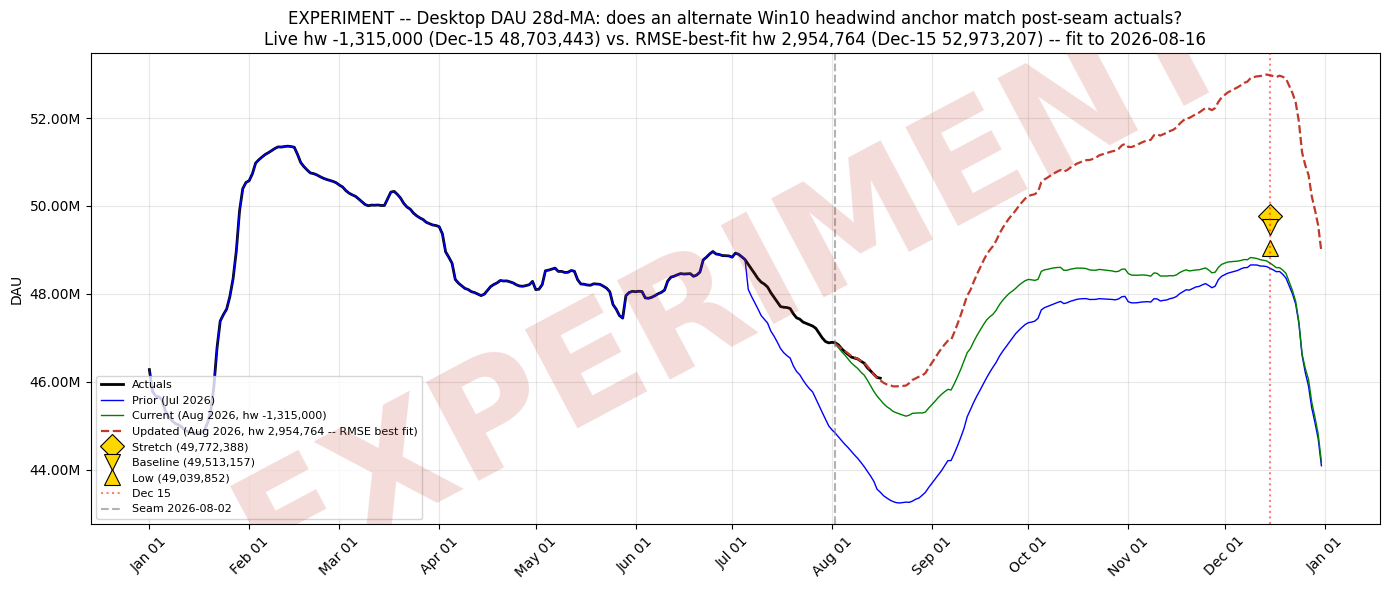

In [9]:
# [plot-comparison]
# Same style as the canonical August desktop chart (data-official/2026-08/august_canonical_v2026-07-28.ipynb,
# render_desktop_plot): same x-axis span, stakeholder markers, colors for Actuals/Prior/Current --
# plus a fourth line for the retuned-headwind curve, and an EXPERIMENT watermark since nothing here
# is published.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(clip_display(desktop_actual_ma), label="Actuals", color="black", linewidth=2)
ax.plot(clip_display(prev_desktop_ma), label="Prior (Jul 2026)", color="blue", linewidth=1)
ax.plot(clip_forecast_only(desktop_ma_live), label=f"Current (Aug 2026, hw {LIVE_ANCHOR_DAU:,.0f})",
        color="green", linewidth=1)
ax.plot(clip_forecast_only(desktop_ma_best_fit),
        label=f"Updated (Aug 2026, hw {BEST_FIT_ANCHOR:,.0f} -- RMSE best fit)",
        color="#c0392b", linewidth=1.6, linestyle="--")

for value, marker, label in [
    (STAKEHOLDER_DESKTOP_STRETCH, "D", "Stretch"),
    (STAKEHOLDER_DESKTOP_BASELINE, "v", "Baseline"),
    (STAKEHOLDER_DESKTOP_LOW, "^", "Low"),
]:
    ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
            markersize=12, markeredgecolor="black", markeredgewidth=0.8,
            linestyle="None", label=f"{label} ({value:,})")

ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.axvline(FORECAST_START, color="grey", linestyle="--", alpha=0.6,
           label=f"Seam {FORECAST_START.date()}")
ax.set_title(
    "EXPERIMENT -- Desktop DAU 28d-MA: does an alternate Win10 headwind anchor match post-seam actuals?\n"
    f"Live hw {LIVE_ANCHOR_DAU:,.0f} (Dec-15 {desktop_ma_live.loc[MEASUREMENT_DATE]:,.0f}) vs. "
    f"RMSE-best-fit hw {BEST_FIT_ANCHOR:,.0f} (Dec-15 {desktop_ma_best_fit.loc[MEASUREMENT_DATE]:,.0f}) "
    f"-- fit to {fit_idx.max().date()}",
    fontsize=12,
)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc="lower left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
add_experiment_watermark(ax)
plt.tight_layout()
out = f"{PLOTS_DIR}/desktop_headwind_retune_experiment.png"
fig.savefig(out, dpi=130)
print(f"saved: {out}")
plt.show()


saved: research/headwinds/aug-post-seam-retune/plots/rmse_vs_headwind_anchor.png


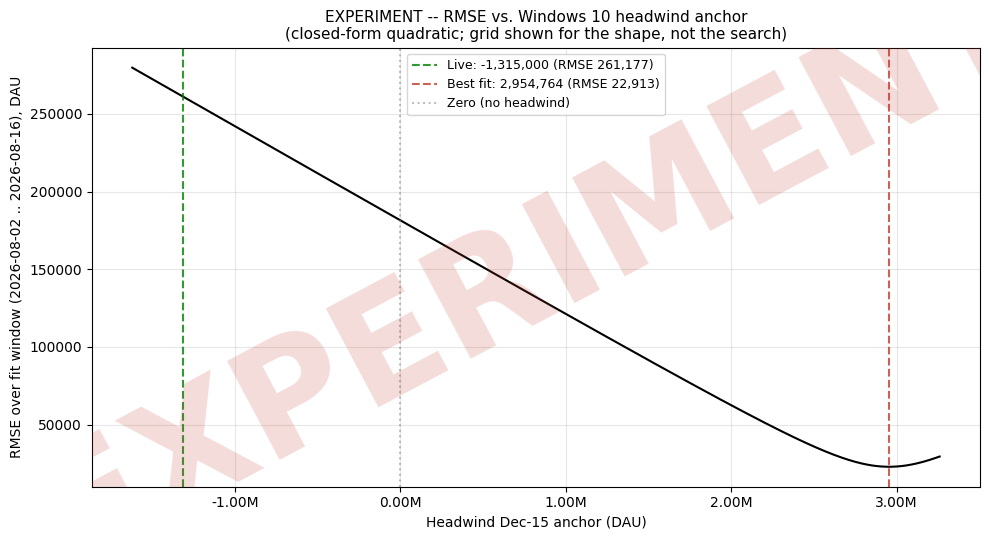

In [10]:
# [plot-rmse-curve]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(grid_df["headwind_anchor_dau"], grid_df["rmse"], color="black", linewidth=1.5)
ax.axvline(LIVE_ANCHOR_DAU, color="green", linestyle="--", alpha=0.8,
           label=f"Live: {LIVE_ANCHOR_DAU:,.0f} (RMSE {RMSE_LIVE:,.0f})")
ax.axvline(BEST_FIT_ANCHOR, color="#c0392b", linestyle="--", alpha=0.8,
           label=f"Best fit: {BEST_FIT_ANCHOR:,.0f} (RMSE {RMSE_BEST:,.0f})")
ax.axvline(0, color="grey", linestyle=":", alpha=0.5, label="Zero (no headwind)")
ax.set_xlabel("Headwind Dec-15 anchor (DAU)")
ax.set_ylabel(f"RMSE over fit window ({fit_idx.min().date()} .. {fit_idx.max().date()}), DAU")
ax.set_title("EXPERIMENT -- RMSE vs. Windows 10 headwind anchor\n"
             "(closed-form quadratic; grid shown for the shape, not the search)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc="upper center", fontsize=9)
ax.grid(True, alpha=0.3)
add_experiment_watermark(ax)
plt.tight_layout()
out = f"{PLOTS_DIR}/rmse_vs_headwind_anchor.png"
fig.savefig(out, dpi=130)
print(f"saved: {out}")
plt.show()


<!-- [conclusion] -->
## Experiment 1 result

| | anchor (Dec-15 DAU) | RMSE over fit window | Dec-15 desktop | Dec-15 − stakeholder Low |
|---|--:|--:|--:|--:|
| Live (published) | **−1,315,000** | 261,177 | 48,703,443 | −336,409 |
| Best fit (this experiment) | **+2,954,764** | 22,913 | 52,973,207 | **+3,933,355** |

Fit window: 2026-08-02 → 2026-08-16, 15 days, **11.1%** of the 135-day ramp.

**The unconstrained best fit is not a smaller headwind — it is a large positive tailwind
(+2,954,764 at Dec-15), reported exactly as asked, with no floor at zero.**

## Why the number is this extreme — read the plot, not just the table

`plots/desktop_headwind_retune_experiment.png` shows why: the "Updated" line has to shoot *above*
July's own curve, above the current August curve, and above even the Stretch stakeholder marker,
peaking near 53M in December before the model's own seasonal Dec decline drags every curve back down
together. That is what it takes to make a **linear ramp anchored at Dec-15** pass through 15 days of
data that have only accrued **11% of that ramp's length**.

This is a structural property of the fit, not a modeling error: the anchor is a slope estimated from
a very short, noisy lever arm (`f(t)` maxes out at 15/135 ≈ 0.111 over the fit window), so a modest,
plausibly noisy residual trend early in the ramp gets extrapolated ~9x forward to Dec-15. The
`plots/rmse_vs_headwind_anchor.png` curve is a smooth, well-behaved parabola — the fit itself is
numerically fine — but a well-behaved fit to 11% of a ramp is still an extrapolation over the
remaining 89%, and this result should be read as "what today's few percent of the year says about
the whole ramp," not as a validated Dec-15 forecast. **Nothing here should be adopted as-is.**

Full grid: `results/headwind_grid.csv` (489 candidate anchors, 10,000-DAU step).


<!-- [exp2-intro] -->
---

# EXPERIMENT 2 — original headwind, model refit through 2026-08-16

Experiment 1 (above) held the model fixed and searched the headwind anchor. **This experiment does
the opposite**: the headwind stays at its published **−1,315,000**, and the *model* is re-run against
every day of data we now have.

| | published build | this refit |
|---|---|---|
| training through | 2026-08-01 | **2026-08-16** (+15 days) |
| seam (forecast start) | 2026-08-02 | **2026-08-17** |
| desktop model config | g01 | **g01, byte-identical** |
| `l` / `o` overlays | applied | applied, **same curves carried forward** |
| `h` headwind anchor | −1,315,000 | **−1,315,000, unchanged** |

So the only thing that varies is the training window. Everything the published build decided —
model config, overlay curves, headwind magnitude — is held exactly as-is, which makes the Dec-15
difference attributable to **fresher data alone**.

Two mechanical notes:

- The refit is a genuine new model run (`run_refit.py` in this directory → `refit_2026-08-17/`),
  not a display-layer recomputation. `l`/`o` are baked into its parquet, same as canonical.
- The headwind **ramp start moves with the seam** (2026-08-02 → 2026-08-17, a 120-day ramp, was
  135), following this cycle's established convention that `h` ramps from the seam forward. Because
  the ramp is anchored on Dec-15, **this does not change the Dec-15 value at all** — it only changes
  the interior shape. The anchor magnitude itself is untouched.

Still an experiment: nothing here is adopted, and no live spec was edited. August's `l`/`o` specs are
date-gated to 2026-08-02, so `run_refit.py` carries them forward past that gate deliberately —
without it the overlays would silently drop out and the refit would not be comparable to the
published `adj-lo` build.


In [11]:
# [exp2-load]
REFIT_FORECAST_START = pd.Timestamp("2026-08-17")
REFIT_FORECAST_PATH = (
    "research/headwinds/aug-post-seam-retune/refit_2026-08-17/"
    "mozaic_daily_forecast.2026-08-17.ld-D.adj-lo.parquet"
)

refit_raw, refit_meta = load_all_level_dau(
    REFIT_FORECAST_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=["l", "o"])

refit_last_train = refit_raw.loc[refit_raw["data_type"] == "training", "target_date"].max()
print(f"Refit: {len(refit_raw)} rows | seam {REFIT_FORECAST_START.date()} "
      f"| last training day {refit_last_train.date()}")
assert refit_last_train == LAST_ACTUAL_DATE, (
    f"Refit trained through {refit_last_train.date()} but the freshest landed actual is "
    f"{LAST_ACTUAL_DATE.date()} -- the refit is supposed to use ALL available data."
)

# The refit must be the SAME model config as published g01: this experiment varies the training
# window and nothing else. Asserted rather than trusted, so a config typo can't masquerade as a
# data effect.
refit_config = refit_meta["model_config"]
published_config = desktop_meta["model_config"]
config_drift = {k: (published_config.get(k), refit_config.get(k))
                for k in published_config
                if refit_config.get(k) != published_config.get(k)}
assert not config_drift, f"refit config differs from published g01: {config_drift}"
print(f"Refit config matches published g01 exactly ({len(published_config)} params checked) "
      f"-- the only difference is the training window")


Refit: 2922 rows | seam 2026-08-17 | last training day 2026-08-16
Refit config matches published g01 exactly (11 params checked) -- the only difference is the training window


In [12]:
# [exp2-curve]
# Same display-layer treatment the canonical notebook applies, with the headwind anchor UNCHANGED
# at its published value. The ramp start moves to the new seam, following this cycle's convention
# that `h` ramps from the seam forward -- which leaves Dec-15 untouched (the ramp is anchored there)
# and changes only the interior shape.
refit_raw_ma = display_ma(refit_raw["target_date"], refit_raw["dau"], REFIT_FORECAST_START)

refit_headwind_spec = {
    "type": "linear_ramp",
    "start_date": str(REFIT_FORECAST_START.date()),
    "anchor_date": str(RAMP_ANCHOR_DATE.date()),
    "desktop_dau": LIVE_ANCHOR_DAU,   # unchanged -1,315,000
    "mobile_dau": 0,
}
refit_rendered = render_adjustment(refit_headwind_spec, refit_raw_ma.index)
desktop_ma_refit = apply_net_adjustment_to_series(
    refit_raw_ma, refit_rendered, "desktop", forecast_start=REFIT_FORECAST_START)

REFIT_RAMP_DAYS = (RAMP_ANCHOR_DATE - REFIT_FORECAST_START).days
DEC15_REFIT_RAW = float(refit_raw_ma.loc[MEASUREMENT_DATE])
DEC15_REFIT = float(desktop_ma_refit.loc[MEASUREMENT_DATE])

print(f"Headwind carried forward unchanged: {LIVE_ANCHOR_DAU:,.0f} at {RAMP_ANCHOR_DATE.date()}")
print(f"  ramp {REFIT_FORECAST_START.date()} -> {RAMP_ANCHOR_DATE.date()} "
      f"({REFIT_RAMP_DAYS} days; published build's ramp was {RAMP_TOTAL_DAYS} days)")
print(f"  net adjustment at Dec-15: {refit_rendered['desktop'].loc[MEASUREMENT_DATE]:+,.0f} DAU")
print()
print(f"Refit Dec-15, model only (no h): {DEC15_REFIT_RAW:,.0f}")
print(f"Refit Dec-15, published h applied: {DEC15_REFIT:,.0f}")


Headwind carried forward unchanged: -1,315,000 at 2026-12-15
  ramp 2026-08-17 -> 2026-12-15 (120 days; published build's ramp was 135 days)
  net adjustment at Dec-15: -1,315,000 DAU

Refit Dec-15, model only (no h): 50,150,825
Refit Dec-15, published h applied: 48,835,825


In [13]:
# [exp2-table]
# Fit quality is reported over the SAME window Experiment 1 used, so the two experiments are
# comparable on the same yardstick. Note the refit's own training rows cover that whole window --
# for the refit these are in-sample residuals, so this column measures "does the fitted curve
# track the data it saw", NOT out-of-sample skill. Read it as descriptive, not as validation.
def rmse_against_actuals(curve, index):
    resid = desktop_actual_ma.reindex(index).to_numpy(float) - curve.reindex(index).to_numpy(float)
    return float(np.sqrt(np.mean(resid**2)))


DEC15_PUBLISHED = float(desktop_ma_live.loc[MEASUREMENT_DATE])
DEC15_PREV_JULY = float(prev_desktop_ma.loc[MEASUREMENT_DATE])

rows = [
    {
        "build": "Prior (July delivered)",
        "trained_through": "2026-07-05",
        "headwind_anchor": prev_net_adjustments["desktop"].loc[MEASUREMENT_DATE],
        "dec15_desktop_dau": DEC15_PREV_JULY,
        "vs_published": DEC15_PREV_JULY - DEC15_PUBLISHED,
        "vs_stakeholder_low": DEC15_PREV_JULY - STAKEHOLDER_DESKTOP_LOW,
        "rmse_exp1_window": rmse_against_actuals(prev_desktop_ma, fit_idx),
    },
    {
        "build": "Published (Aug, g01)",
        "trained_through": str(last_train.date()),
        "headwind_anchor": LIVE_ANCHOR_DAU,
        "dec15_desktop_dau": DEC15_PUBLISHED,
        "vs_published": 0.0,
        "vs_stakeholder_low": DEC15_PUBLISHED - STAKEHOLDER_DESKTOP_LOW,
        "rmse_exp1_window": RMSE_LIVE,
    },
    {
        "build": "EXP 2 refit (same h)",
        "trained_through": str(refit_last_train.date()),
        "headwind_anchor": LIVE_ANCHOR_DAU,
        "dec15_desktop_dau": DEC15_REFIT,
        "vs_published": DEC15_REFIT - DEC15_PUBLISHED,
        "vs_stakeholder_low": DEC15_REFIT - STAKEHOLDER_DESKTOP_LOW,
        "rmse_exp1_window": rmse_against_actuals(desktop_ma_refit, fit_idx),
    },
]
results_exp2 = pd.DataFrame(rows)

results_csv_path = f"{RESULTS_DIR}/refit_2026-08-16_results.csv"
results_exp2.to_csv(results_csv_path, index=False)
print(f"saved: {results_csv_path}\n")

print(f"{'build':24s}{'trained thru':>14s}{'h anchor':>13s}{'Dec-15':>13s}"
      f"{'vs published':>14s}{'vs Low':>13s}{'RMSE*':>10s}")
for _, row in results_exp2.iterrows():
    print(f"{row['build']:24s}{row['trained_through']:>14s}{row['headwind_anchor']:>13,.0f}"
          f"{row['dec15_desktop_dau']:>13,.0f}{row['vs_published']:>+14,.0f}"
          f"{row['vs_stakeholder_low']:>+13,.0f}{row['rmse_exp1_window']:>10,.0f}")
print(f"\n* RMSE over {fit_idx.min().date()}..{fit_idx.max().date()} -- IN-SAMPLE for the refit "
      f"(it trained on those days), so not a skill comparison.")
print(f"\nData effect of 15 more training days, holding h and the config fixed: "
      f"{DEC15_REFIT - DEC15_PUBLISHED:+,.0f} DAU at Dec-15")


saved: research/headwinds/aug-post-seam-retune/results/refit_2026-08-16_results.csv

build                     trained thru     h anchor       Dec-15  vs published       vs Low     RMSE*
Prior (July delivered)      2026-07-05   -1,345,000   48,585,483      -117,960     -454,369 2,274,687
Published (Aug, g01)        2026-08-01   -1,315,000   48,703,443            +0     -336,409   261,177
EXP 2 refit (same h)        2026-08-16   -1,315,000   48,835,825      +132,382     -204,027         1

* RMSE over 2026-08-02..2026-08-16 -- IN-SAMPLE for the refit (it trained on those days), so not a skill comparison.

Data effect of 15 more training days, holding h and the config fixed: +132,382 DAU at Dec-15


saved: research/headwinds/aug-post-seam-retune/plots/desktop_refit_through_2026-08-16.png


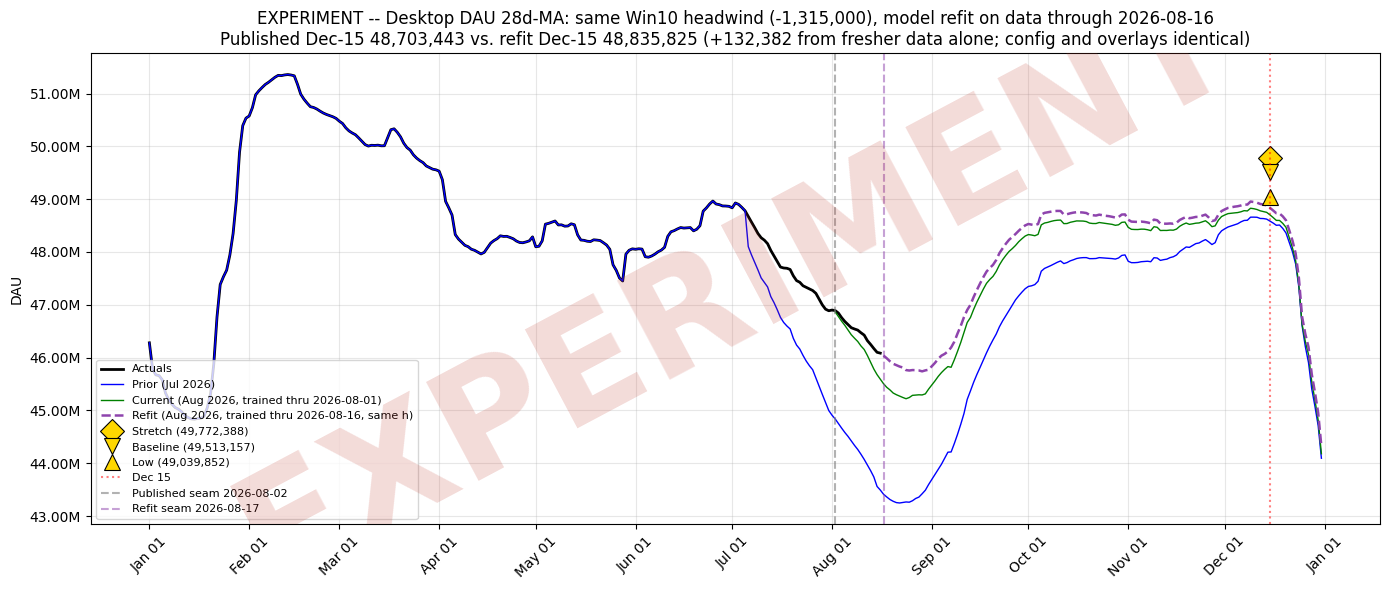

In [14]:
# [exp2-plot]
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(clip_display(desktop_actual_ma), label="Actuals", color="black", linewidth=2)
ax.plot(clip_display(prev_desktop_ma), label="Prior (Jul 2026)", color="blue", linewidth=1)
ax.plot(clip_forecast_only(desktop_ma_live), label=f"Current (Aug 2026, trained thru {last_train.date()})",
        color="green", linewidth=1)
ax.plot(clip_forecast_only(desktop_ma_refit, REFIT_FORECAST_START),
        label=f"Refit (Aug 2026, trained thru {refit_last_train.date()}, same h)",
        color="#8e44ad", linewidth=1.8, linestyle="--")

for value, marker, label in [
    (STAKEHOLDER_DESKTOP_STRETCH, "D", "Stretch"),
    (STAKEHOLDER_DESKTOP_BASELINE, "v", "Baseline"),
    (STAKEHOLDER_DESKTOP_LOW, "^", "Low"),
]:
    ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
            markersize=12, markeredgecolor="black", markeredgewidth=0.8,
            linestyle="None", label=f"{label} ({value:,})")

ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.axvline(FORECAST_START, color="grey", linestyle="--", alpha=0.6,
           label=f"Published seam {FORECAST_START.date()}")
ax.axvline(REFIT_FORECAST_START, color="#8e44ad", linestyle="--", alpha=0.5,
           label=f"Refit seam {REFIT_FORECAST_START.date()}")
ax.set_title(
    "EXPERIMENT -- Desktop DAU 28d-MA: same Win10 headwind (-1,315,000), model refit on data through "
    f"{refit_last_train.date()}\n"
    f"Published Dec-15 {DEC15_PUBLISHED:,.0f} vs. refit Dec-15 {DEC15_REFIT:,.0f} "
    f"({DEC15_REFIT - DEC15_PUBLISHED:+,.0f} from fresher data alone; config and overlays identical)",
    fontsize=12,
)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc="lower left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
add_experiment_watermark(ax)
plt.tight_layout()
out = f"{PLOTS_DIR}/desktop_refit_through_2026-08-16.png"
fig.savefig(out, dpi=130)
print(f"saved: {out}")
plt.show()


<!-- [exp2-conclusion] -->
## Experiment 2 result

| build | trained through | `h` anchor | Dec-15 desktop | vs. published | vs. stakeholder Low |
|---|---|--:|--:|--:|--:|
| Prior (July delivered) | 2026-07-05 | −1,345,000 | 48,585,483 | −117,960 | −454,369 |
| Published (Aug, g01) | 2026-08-01 | −1,315,000 | 48,703,443 | — | −336,409 |
| **EXP 2 refit (same `h`)** | **2026-08-16** | −1,315,000 | **48,835,825** | **+132,382** | **−204,027** |

**Holding the headwind, the model config, and the `l`/`o` overlays all fixed, 15 extra days of
training data move desktop Dec-15 by +132,382 DAU** — and close about 39% of the gap to the
stakeholder Low marker (−336,409 → −204,027), without touching the headwind at all.

That is a far more modest and more plausible answer than Experiment 1's, and it is worth noting why:
here the fresher data is absorbed by Prophet's fit to the whole training history, so its influence on
Dec-15 is damped. In Experiment 1 the same fresher data had to be explained *entirely* by a single
Dec-15-anchored ramp fitted from 11% of its length, so it got amplified into a +2.95M anchor. Same
data, two very different levers.

**The RMSE column in the printed table is degenerate for the refit and should not be read as
validation.** The refit trained *through* 2026-08-16, so over the 2026-08-02 → 2026-08-16 comparison
window its curve is training rows — which are byte-identical to actuals by construction — giving an
RMSE of ~1. It measures nothing about forecast skill. There is no out-of-sample window available for
the refit yet; establishing one requires waiting for days it has not seen.

Direction of the result is consistent between the two experiments — actuals are running above the
published curve, and both levers move Dec-15 up — but only the magnitudes here are on a scale worth
discussing. **Still an experiment; nothing adopted, no live spec touched.**

Artifacts: `refit_2026-08-17/` (the new build, `.adj-lo.` + sidecar),
`results/refit_2026-08-16_results.csv`, `plots/desktop_refit_through_2026-08-16.png`.
